In [1]:
"""
Rolling Window vs EWMA Network Analysis
MST Analysis of ETF Sector Correlations (refactor from other's code)

This notebook:
1. Applies Rolling Window and EWMA smoothing
2. Builds Minimum Spanning Tree (MST) networks
3. Compares correlation structure over time
"""
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy.sparse.csgraph import minimum_spanning_tree

plt.style.use("ggplot")

In [2]:
class RollingWindow:

    def __init__(self,
                 time_series: np.ndarray,
                 window_sz: int = 252,
                 useWeight: bool = False,
                 weights: np.ndarray | None = None,
                 alpha: float | None = 0.3,
                 theta: float | None = None):
        """
        :param time_series:     Time series data
        :param window_sz:       The size of the rolling window.
        :param useWeight:       The flag to use weighted rolling window.
        :param weights:         Specified weights
        :param alpha:           The alpha parameter in exponential smoothing.
        """

        self.__data_DF = pd.DataFrame(time_series)

        self.__window_sz = window_sz
        self.__useWeight = useWeight
        self.__weights = weights
        self.__alpha = alpha
        self.__theta = theta

    def rolling_window(self):
        """
        Method to generate moving average(rolling window).
        :return: moving average: μ_{t, Δ}
        """

        # If the weights are not specified, then generate exponential weights.
        if not self.__useWeight:
            return self.__data_DF.rolling(self.__window_sz).mean()

        weights = self.__weights        # normalization of weight

        if weights is None:
            self.__theta = self.__window_sz / 3.0
            weights = np.array([self.__theta ** (-i) for i in range(self.__window_sz)])
            weights = weights / weights.sum()

        return self.__data_DF.rolling(self.__window_sz).apply(
            lambda x: np.dot(x, weights),
            raw=True
        )

    def exponential_smooth(self):
        """
        Method to generate exponential smoothing.
        :return: exponential smoothing: μ_{t, Δ}
        """
        data = self.__data_DF.values
        mu = np.zeros_like(data)

        mu[0] = data[0]

        for i in range(1, len(data)):
            mu[i] = self.__alpha * data[i] + (1 - self.__alpha) * mu[i-1]

        return pd.DataFrame(mu,
                            index=self.__data_DF.index,
                            columns=self.__data_DF.columns)

    def RW_Expo_diff(self):
        """
        Method to compare two series generated by self.rolling_window() and self.exponential_smooth().
        :return:
        """
        alpha_expr = 1 - np.exp(-3 / self.__window_sz)

        if self.__alpha is None:
            self.__alpha = alpha_expr

        rolling_window = self.rolling_window()
        exponential_smooth = self.exponential_smooth()

        return exponential_smooth - rolling_window

In [3]:
class MSTAnalyzer:

    def __init__(self, returns: pd.DataFrame):

        self.returns = returns
        self.tickers = returns.columns.tolist()

    def mst_graph(self, D):

        mst_sparse = minimum_spanning_tree(D)
        mst_coo = mst_sparse.tocoo()

        G = nx.Graph()
        G.add_nodes_from(self.tickers)

        for u, v, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):

            G.add_edge(self.tickers[u],
                       self.tickers[v],
                       weight=float(w))

        return G

    def compute_pipeline(self,
                         epoch_length=40,
                         epoch_shift=20):

        graphs = []
        corr_list = []
        mu = []
        dates = []

        data = self.returns

        for i in range(0, len(data) - epoch_length, epoch_shift):

            epoch = data.iloc[i:i+epoch_length]

            C = epoch.corr().values
            corr_list.append(C)

            D = np.sqrt(2*(1-C))

            mu.append(np.mean(C))

            if isinstance(epoch.index, pd.DatetimeIndex):
                dates.append(epoch.index[-1])
            else:
                dates.append(i)

            G = self.mst_graph(D)

            graphs.append(G)

        return graphs, corr_list, mu, dates

    def tree_length(self, G):

        return sum(d['weight'] for (_,_,d) in G.edges(data=True))

    def plot_corr_and_mst(self, C, G, date, title):

        fig, axes = plt.subplots(1,2, figsize=(14,7))

        im = axes[0].imshow(C, vmin=-1, vmax=1, cmap="coolwarm")

        axes[0].set_title(f"Correlation Matrix\n{date}")

        axes[0].set_xticks(range(len(self.tickers)))
        axes[0].set_yticks(range(len(self.tickers)))

        axes[0].set_xticklabels(self.tickers, rotation=90)
        axes[0].set_yticklabels(self.tickers)

        for i in range(len(self.tickers)):
            for j in range(len(self.tickers)):
                axes[0].text(j, i, f"{C[i,j]:.2f}",
                             ha="center",
                             va="center",
                             fontsize=8)

        fig.colorbar(im, ax=axes[0])

        pos = nx.spring_layout(G, seed=42)

        nx.draw_networkx_nodes(G, pos, ax=axes[1],
                               node_size=400,
                               node_color="black")

        nx.draw_networkx_edges(G, pos, ax=axes[1],
                               width=2,
                               edge_color="red")

        nx.draw_networkx_labels(G, pos, ax=axes[1],
                                font_color="white")

        axes[1].set_title(title)

        plt.tight_layout()
        plt.show()

In [4]:
df_price = pd.read_csv("sector_prices_2000.csv")

df_price["Date"] = pd.to_datetime(df_price["Date"])

df_price.head()

,Date,XLP,XLI,XLK,XLF,XLE,XLV,XLB,XLY,XLU
0,2000-01-03,12.207147,18.125662,20.652031,11.147916,6.699403,20.524771,7.260403,11.173436,5.551600
1,2000-01-04,11.863401,17.624907,19.604292,10.660575,6.573298,20.059025,7.190504,10.837304,5.384134
2,2000-01-05,12.073009,17.546349,19.313259,10.576812,6.746696,19.879076,7.487564,10.704011,5.520001
3,2000-01-06,12.299372,17.782009,18.672976,11.041312,7.006788,19.942591,7.679775,10.825714,5.510522
4,2000-01-07,13.079085,18.459503,18.998934,11.224065,7.081663,20.186050,7.675409,11.335704,5.557922


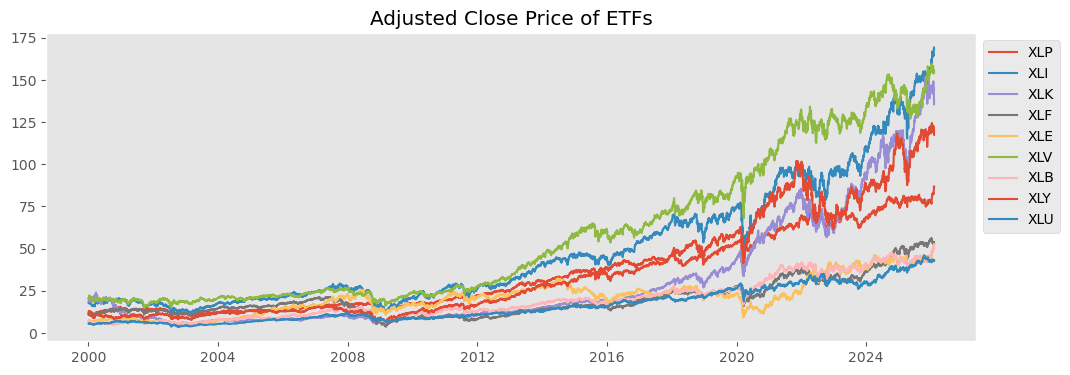

In [5]:
plt.figure(figsize=(12,4))

for col in df_price.columns[1:]:
    plt.plot(df_price["Date"], df_price[col], label=col)

plt.title("Adjusted Close Price of ETFs")

plt.legend(loc="upper left", bbox_to_anchor=(1,1))
plt.grid()

plt.show()

In [6]:
df_log = pd.DataFrame()
df_log["Date"] = df_price["Date"]

for col in df_price.columns[1:]:

    s = df_price[col].replace(0, np.nan)

    df_log[col] = np.log(s / s.shift(1))

df_log = df_log.dropna()

returns = df_log.iloc[:,1:]
returns.index = df_log["Date"]

returns.head()

,XLP,XLI,XLK,XLF,XLE,XLV,XLB,XLY,XLU
Date,,,,,,,,,
2000-01-04,-0.028563,-0.028016,-0.052065,-0.044700,-0.019003,-0.022953,-0.009674,-0.030545,-0.030630
2000-01-05,0.017514,-0.004467,-0.014957,-0.007888,0.026037,-0.009011,0.040482,-0.012376,0.024922
2000-01-06,0.018576,0.013341,-0.033715,0.042980,0.037827,0.003190,0.025347,0.011306,-0.001719
2000-01-07,0.061466,0.037392,0.017306,0.016416,0.010629,0.012134,-0.000569,0.046033,0.008565
2000-01-10,-0.022691,0.000000,0.037286,-0.017797,-0.008382,0.097358,-0.003421,-0.005125,0.003405


In [7]:
rw = RollingWindow(returns.values)

returns_rw = rw.rolling_window()
returns_rw.index = returns.index
returns_rw.columns = returns.columns
returns_rw = returns_rw.dropna()

returns_ewma = rw.exponential_smooth()
returns_ewma.index = returns.index
returns_ewma.columns = returns.columns

In [8]:
raw_net = MSTAnalyzer(returns)
rw_net = MSTAnalyzer(returns_rw)
ewma_net = MSTAnalyzer(returns_ewma)

graphs_raw, corr_raw, mu_raw, dates_raw = raw_net.compute_pipeline()
graphs_rw, corr_rw, mu_rw, dates_rw = rw_net.compute_pipeline()
graphs_ewma, corr_ewma, mu_ewma, dates_ewma = ewma_net.compute_pipeline()

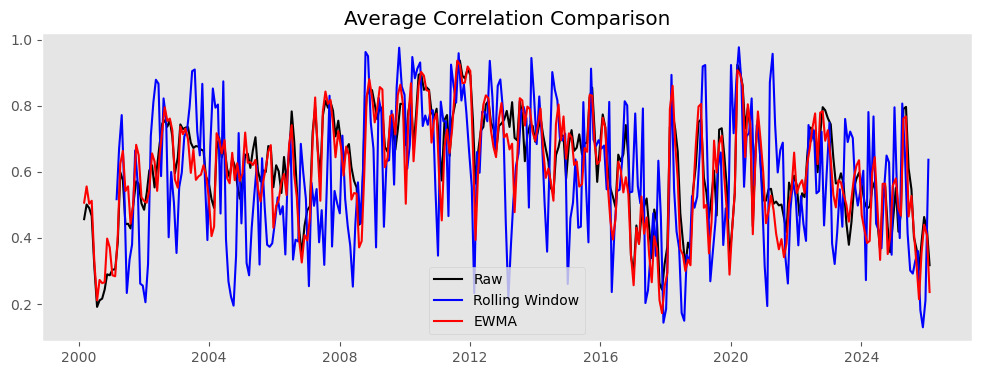

In [9]:
plt.figure(figsize=(12,4))

plt.plot(dates_raw, mu_raw, label="Raw", color="black")
plt.plot(dates_rw, mu_rw, label="Rolling Window", color="blue")
plt.plot(dates_ewma, mu_ewma, label="EWMA", color="red")

plt.title("Average Correlation Comparison")

plt.legend()
plt.grid()

plt.show()

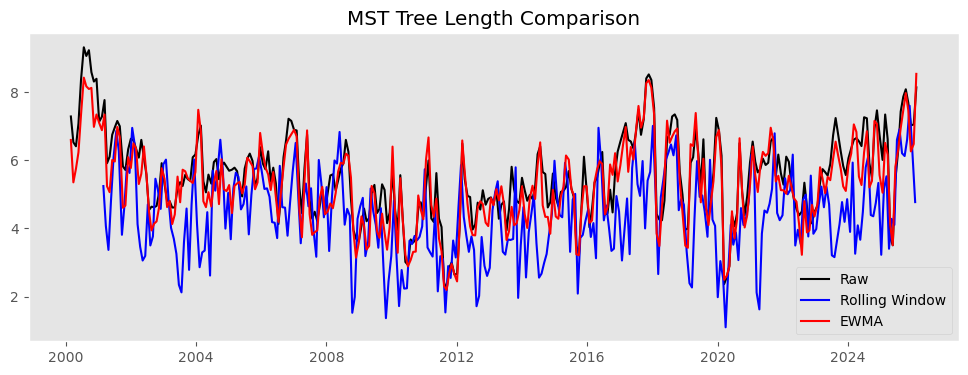

In [10]:
tree_raw = [raw_net.tree_length(g) for g in graphs_raw]
tree_rw = [rw_net.tree_length(g) for g in graphs_rw]
tree_ewma = [ewma_net.tree_length(g) for g in graphs_ewma]

plt.figure(figsize=(12,4))

plt.plot(dates_raw, tree_raw, label="Raw", color="black")
plt.plot(dates_rw, tree_rw, label="Rolling Window", color="blue")
plt.plot(dates_ewma, tree_ewma, label="EWMA", color="red")

plt.title("MST Tree Length Comparison")

plt.legend()
plt.grid()

plt.show()

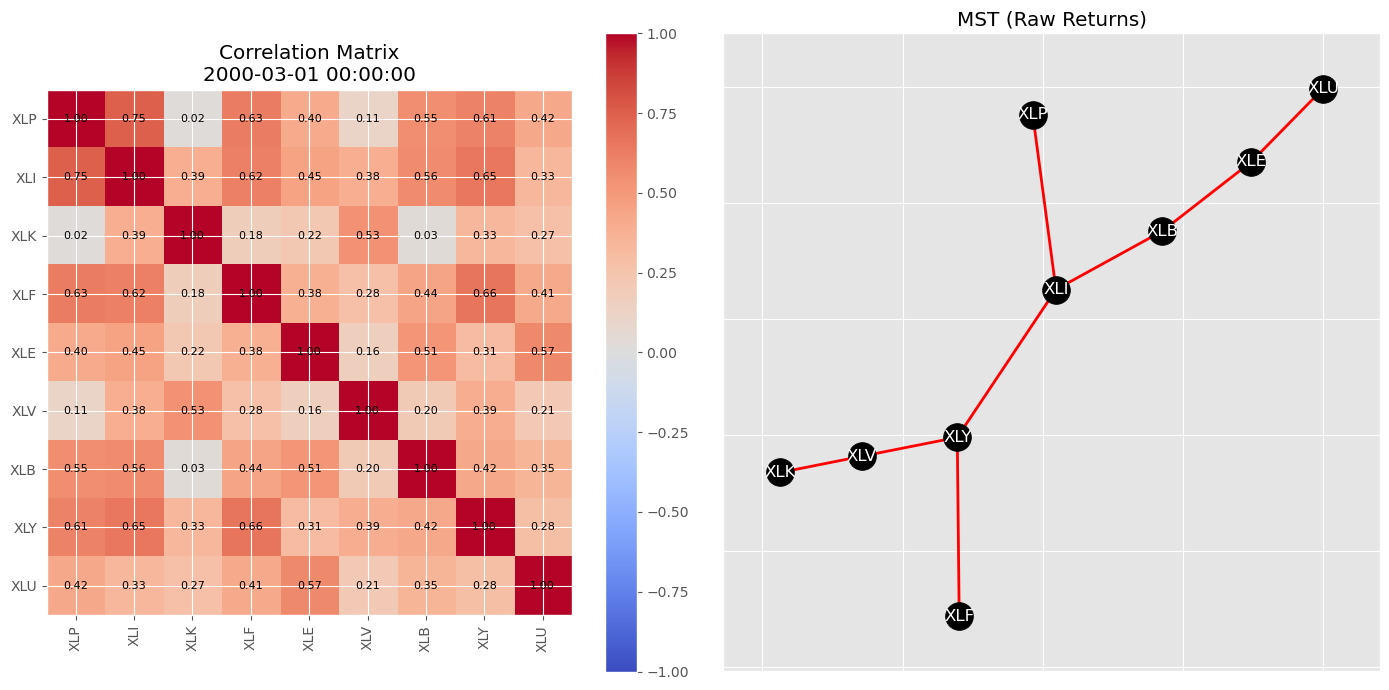

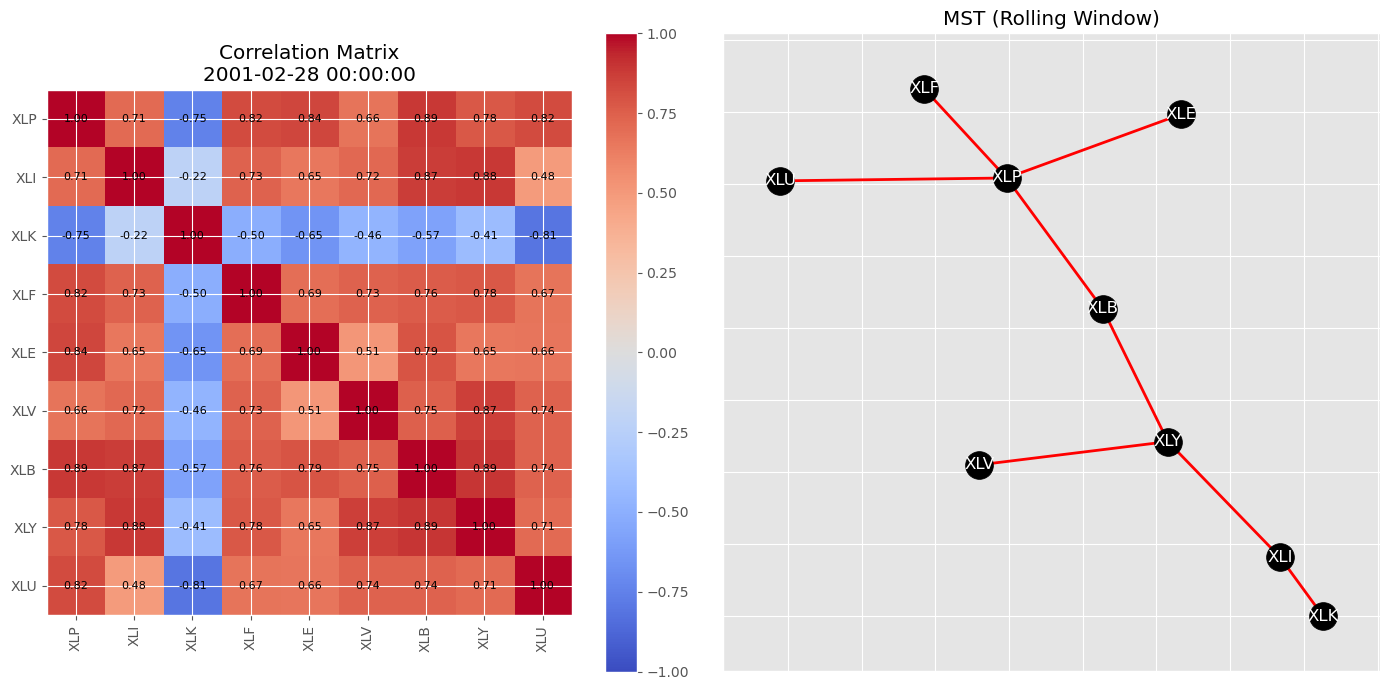

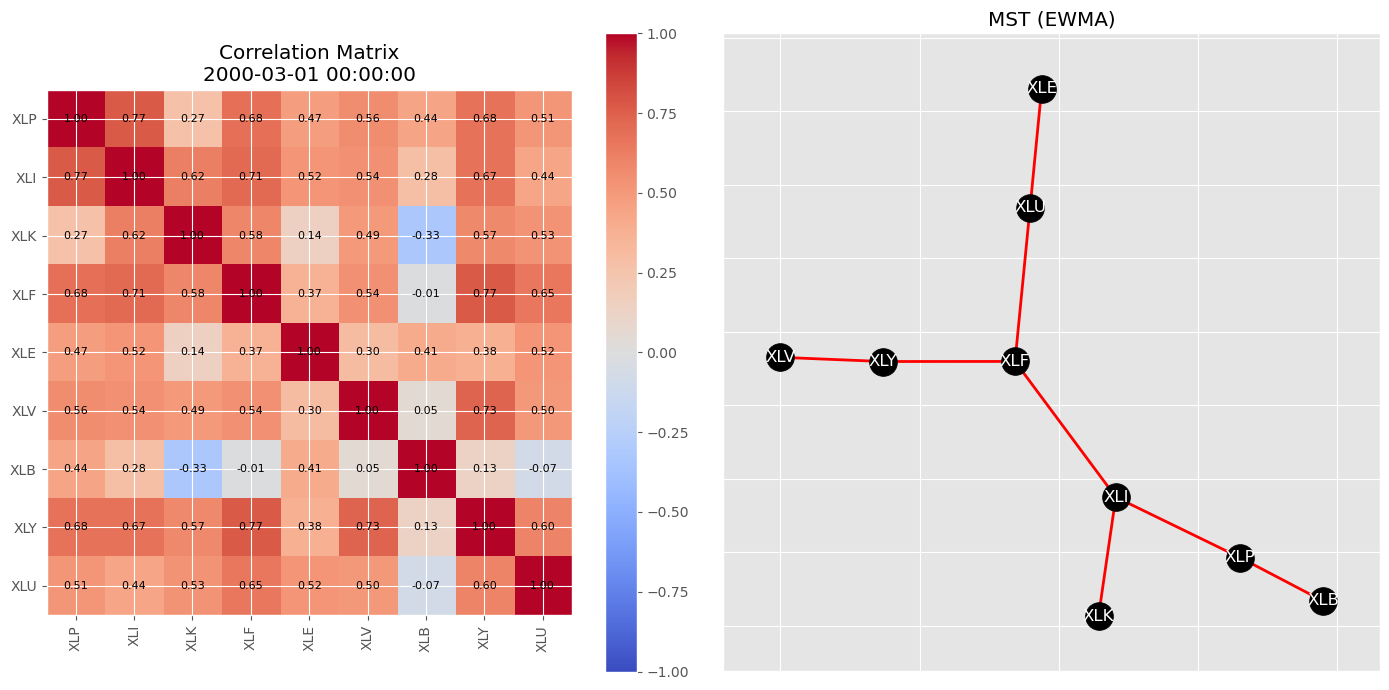

In [11]:
raw_net.plot_corr_and_mst(
    corr_raw[0],
    graphs_raw[0],
    dates_raw[0],
    "MST (Raw Returns)"
)

rw_net.plot_corr_and_mst(
    corr_rw[0],
    graphs_rw[0],
    dates_rw[0],
    "MST (Rolling Window)"
)

ewma_net.plot_corr_and_mst(
    corr_ewma[0],
    graphs_ewma[0],
    dates_ewma[0],
    "MST (EWMA)"
)